# Canadian Tech Job Market Analysis: Post-Claude Code Era (Feb 2025 – Present)

**Data Span**: January 2023 to July 2026 (Job Bank Canada microdata) & August 2026 (Indeed tech sector indices)  
**Historical Context**: In **February 2025**, Anthropic released the research preview of **Claude Code**, accelerating the industry-wide transition toward autonomous agentic coding workflows alongside platforms like Windsurf and Cursor.

This notebook delivers an empirical investigation into the Canadian tech labor market during this transformative period, addressing key data integrity and macroeconomic questions:
1. **Source Coverage & Deduplication**: Dissecting internal Job Bank direct postings vs. external job board aggregators, removing multi-month snapshot redundancies and cross-source duplicates.
2. **Season-Matched Comparative Analysis**: Comparing identical calendar months (**February through July**, Months 2–7) across 2023, 2024, 2025, and 2026 to eliminate seasonal hiring bias (e.g., winter freezes, summer lulls).
3. **Fresh Opportunity Pipeline**: Tracking weekly hiring inflow via a continuous 7-day rolling window on calendar days.
4. **Compensation Distribution**: Standardizing annual and hourly compensation benchmarks (with outlier fliers removed and descriptive quartiles $Q_1$, Median, $Q_3$).
5. **Geographic Concentration**: Mapping regional demand across Canadian provinces and tech hubs.
6. **Macro Validation**: Cross-verifying trends against independent daily tech sector indices from Indeed Canada.


In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Visual styling
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'axes.edgecolor': '#cccccc',
    'axes.linewidth': 0.8,
    'grid.color': '#eaeaea',
    'grid.linestyle': '--',
    'grid.alpha': 0.7,
    'figure.titlesize': 14,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

PLOTS_DIR = Path('plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CACHE_FILE = Path('../../data/job_bank_tech_detail_cache.csv')
INDEED_SECTOR_FILE = Path('../../data/job_postings_by_sector_CA.csv')

print("Environment configured successfully. Ready for post-Claude Code era analysis.")


Environment configured successfully. Ready for post-Claude Code era analysis.


## 1. Source Coverage & Data Deduplication

Job Bank Canada microdata aggregates postings from two distinct channels:
- **Internal Direct Postings (`External Indicator = 0`)**: Jobs posted directly by Canadian employers on the Job Bank portal.
- **External Aggregations (`External Indicator = 1`)**: Postings indexed or scraped by Job Bank from third-party job boards (e.g., Indeed, LinkedIn, employer career sites).

### Data Integrity & Deduplication Pipeline
1. **Multi-Snapshot Duplication**: Job Bank publishes monthly cumulative snapshot CSVs. Because active job listings often remain open for 30–90 days, identical postings appear repeatedly across multiple monthly snapshot files.
2. **Cross-Source Overlap**: Certain employers post directly to Job Bank while the same opening is also aggregated from an external board. In all cross-source overlaps, we prioritize the **internal direct Job Bank posting (`0`)** as the authoritative source.
3. **Deduplication Key**: Postings are deduplicated across `['Role', 'Job Title', 'First Posting Date', 'Province/Territory', 'City']`.

The deduplication reduced the raw tech dataset from **96,848 rows** down to **68,390 clean unique postings**, successfully removing **28,458 duplicate records** (a 29.4% duplication rate).


In [2]:
# Load deduplicated cache
df = pd.read_csv(CACHE_FILE)
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['YearMonth'] = df['Date'].dt.to_period('M')

print(f"Loaded {len(df):,} clean unique tech job postings.")
print(f"Date Range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")

# Source Coverage Breakdown
src_counts = df['External Indicator'].value_counts()
src_pcts = df['External Indicator'].value_counts(normalize=True) * 100

src_summary = pd.DataFrame({
    'Source Channel': ['External Aggregators (Indexed/Scraped)', 'Internal Job Bank (Direct Employer)'],
    'Unique Postings': [src_counts.get(1, 0), src_counts.get(0, 0)],
    'Share (%)': [src_pcts.get(1, 0), src_pcts.get(0, 0)]
})
display(src_summary.style.format({'Unique Postings': '{:,}', 'Share (%)': '{:.2f}%'}))

# Source Coverage by Technical Role
role_src = pd.crosstab(df['Role'], df['External Indicator'], normalize='index') * 100
role_src.columns = ['Internal Direct (%)', 'External Aggregated (%)']
role_src['Total Clean Postings'] = df.groupby('Role').size()
role_src = role_src.sort_values(by='Internal Direct (%)', ascending=False)
display(role_src.style.format({
    'Internal Direct (%)': '{:.1f}%',
    'External Aggregated (%)': '{:.1f}%',
    'Total Clean Postings': '{:,}'
}))


Loaded 68,390 clean unique tech job postings.
Date Range: 2023-01-01 to 2026-07-31


,Source Channel,Unique Postings,Share (%)
0,External Aggregators (Indexed/Scraped),"53,849",78.74%
1,Internal Job Bank (Direct Employer),"14,541",21.26%


,Internal Direct (%),External Aggregated (%),Total Clean Postings
Role,,,
Web Developers & Programmers,47.4%,52.6%,"6,043"
Business Systems Specialists,35.6%,64.4%,"3,840"
Database Analysts & Data Admins,24.5%,75.5%,"6,244"
Software Developers & Programmers,21.9%,78.1%,"13,020"
Software Engineers & Designers,20.4%,79.6%,"9,803"
Computer Systems Developers,20.1%,79.9%,"2,128"
Computer Engineers (non-software),16.3%,83.7%,"2,031"
Data Scientists,15.8%,84.2%,"2,570"
Cybersecurity Specialists,14.2%,85.8%,"3,364"


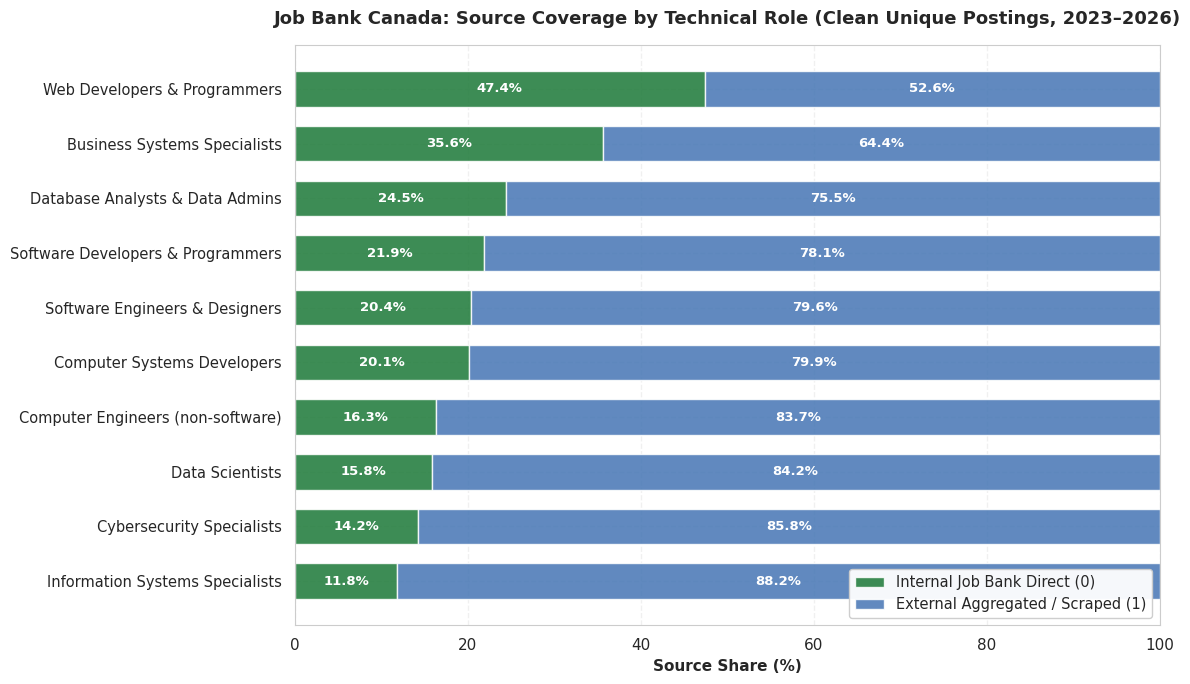

In [3]:
# Plot: Source Coverage by Technical Role
fig, ax = plt.subplots(figsize=(12, 7))

roles_ordered = role_src.index.tolist()
internal_shares = role_src['Internal Direct (%)'].values
external_shares = role_src['External Aggregated (%)'].values

y_pos = np.arange(len(roles_ordered))
bar_width = 0.65

p1 = ax.barh(y_pos, internal_shares, bar_width, label='Internal Job Bank Direct (0)', color='#1b7837', alpha=0.85)
p2 = ax.barh(y_pos, external_shares, bar_width, left=internal_shares, label='External Aggregated / Scraped (1)', color='#4575b4', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(roles_ordered, fontsize=10.5)
ax.invert_yaxis()  # Highest internal at top
ax.set_xlabel('Source Share (%)', fontsize=11, fontweight='bold')
ax.set_title('Job Bank Canada: Source Coverage by Technical Role (Clean Unique Postings, 2023–2026)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlim(0, 100)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.95, fontsize=10.5)

# Value annotations inside bars
for i, (int_val, ext_val) in enumerate(zip(internal_shares, external_shares)):
    ax.text(int_val / 2, i, f"{int_val:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)
    ax.text(int_val + ext_val / 2, i, f"{ext_val:.1f}%", ha='center', va='center', color='white', fontweight='bold', fontsize=9.5)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_source_coverage.png', dpi=300)
plt.show()


## 2. Season-Matched Pre- vs. Post-Claude Comparison (February – July)

### Why Season-Matching is Essential
Labor markets follow strong seasonal patterns:
- **Late Autumn / December**: Budget exhaustions and holiday hiring freezes lead to sharp drops in job listings.
- **January / February**: Re-opening of annual headcount budgets triggers an initial surge.
- **Late Winter & Spring (March – May)**: Prime hiring season across Canadian tech hubs.
- **Mid Summer (July – August)**: Vacation slowdowns create a seasonal plateau.

Comparing whole non-overlapping multi-year blocks (e.g., 25 months pre-Claude vs 18 months post-Claude) introduces seasonal bias. To establish a rigorous, unbiased baseline, we isolate the exact matching 6-month period across all 4 years: **February 1 to July 31 (Months 2–7)**:
- **Feb–Jul 2023**: Pre-Claude Era (Baseline Year 1)
- **Feb–Jul 2024**: Pre-Claude Era (Baseline Year 2)
- **Feb–Jul 2025**: Immediate Post-Claude Era (Claude Code Preview Launch)
- **Feb–Jul 2026**: Mature Agentic Era (Enterprise-wide autonomous coding integration)


In [4]:
# Filter for the exact same 6 months: February to July (Months 2-7)
MATCHED_MONTHS = [2, 3, 4, 5, 6, 7]
df_matched = df[df['Month'].isin(MATCHED_MONTHS)].copy()

# Aggregate by Year and Role
matched_pivot = df_matched.groupby(['Role', 'Year']).size().unstack(fill_value=0)
matched_pivot['Total'] = matched_pivot.sum(axis=1)
matched_pivot = matched_pivot.sort_values(by='Total', ascending=False)

# Compute YoY percentage changes for the matched season
yoy_summary = pd.DataFrame({
    'Feb-Jul 2023 (Pre-Claude 1)': matched_pivot[2023],
    'Feb-Jul 2024 (Pre-Claude 2)': matched_pivot[2024],
    'Feb-Jul 2025 (Post-Claude 1)': matched_pivot[2025],
    'Feb-Jul 2026 (Post-Claude 2)': matched_pivot[2026],
})

yoy_summary['YoY 2023->2024 (%)'] = ((yoy_summary['Feb-Jul 2024 (Pre-Claude 2)'] - yoy_summary['Feb-Jul 2023 (Pre-Claude 1)']) / yoy_summary['Feb-Jul 2023 (Pre-Claude 1)']) * 100
yoy_summary['YoY 2024->2025 (%)'] = ((yoy_summary['Feb-Jul 2025 (Post-Claude 1)'] - yoy_summary['Feb-Jul 2024 (Pre-Claude 2)']) / yoy_summary['Feb-Jul 2024 (Pre-Claude 2)']) * 100
yoy_summary['YoY 2025->2026 (%)'] = ((yoy_summary['Feb-Jul 2026 (Post-Claude 2)'] - yoy_summary['Feb-Jul 2025 (Post-Claude 1)']) / yoy_summary['Feb-Jul 2025 (Post-Claude 1)']) * 100
yoy_summary['Overall Change 2024->2026 (%)'] = ((yoy_summary['Feb-Jul 2026 (Post-Claude 2)'] - yoy_summary['Feb-Jul 2024 (Pre-Claude 2)']) / yoy_summary['Feb-Jul 2024 (Pre-Claude 2)']) * 100

# Append Total Row
totals = yoy_summary.sum(axis=0)
totals.name = 'TOTAL CANADIAN TECH'
totals['YoY 2023->2024 (%)'] = ((totals['Feb-Jul 2024 (Pre-Claude 2)'] - totals['Feb-Jul 2023 (Pre-Claude 1)']) / totals['Feb-Jul 2023 (Pre-Claude 1)']) * 100
totals['YoY 2024->2025 (%)'] = ((totals['Feb-Jul 2025 (Post-Claude 1)'] - totals['Feb-Jul 2024 (Pre-Claude 2)']) / totals['Feb-Jul 2024 (Pre-Claude 2)']) * 100
totals['YoY 2025->2026 (%)'] = ((totals['Feb-Jul 2026 (Post-Claude 2)'] - totals['Feb-Jul 2025 (Post-Claude 1)']) / totals['Feb-Jul 2025 (Post-Claude 1)']) * 100
totals['Overall Change 2024->2026 (%)'] = ((totals['Feb-Jul 2026 (Post-Claude 2)'] - totals['Feb-Jul 2024 (Pre-Claude 2)']) / totals['Feb-Jul 2024 (Pre-Claude 2)']) * 100

yoy_summary_table = pd.concat([yoy_summary, pd.DataFrame([totals])])
display(yoy_summary_table.style.format({
    'Feb-Jul 2023 (Pre-Claude 1)': '{:,.0f}',
    'Feb-Jul 2024 (Pre-Claude 2)': '{:,.0f}',
    'Feb-Jul 2025 (Post-Claude 1)': '{:,.0f}',
    'Feb-Jul 2026 (Post-Claude 2)': '{:,.0f}',
    'YoY 2023->2024 (%)': '{:+.1f}%',
    'YoY 2024->2025 (%)': '{:+.1f}%',
    'YoY 2025->2026 (%)': '{:+.1f}%',
    'Overall Change 2024->2026 (%)': '{:+.1f}%'
}))


,Feb-Jul 2023 (Pre-Claude 1),Feb-Jul 2024 (Pre-Claude 2),Feb-Jul 2025 (Post-Claude 1),Feb-Jul 2026 (Post-Claude 2),YoY 2023->2024 (%),YoY 2024->2025 (%),YoY 2025->2026 (%),Overall Change 2024->2026 (%)
Information Systems Specialists,"4,266","3,459","1,902","1,620",-18.9%,-45.0%,-14.8%,-53.2%
Software Developers & Programmers,"2,372","2,321","1,609",788,-2.2%,-30.7%,-51.0%,-66.0%
Software Engineers & Designers,"1,606","1,952","1,116",569,+21.5%,-42.8%,-49.0%,-70.9%
Database Analysts & Data Admins,"1,414","1,215",613,225,-14.1%,-49.5%,-63.3%,-81.5%
Web Developers & Programmers,"1,037","1,183",677,388,+14.1%,-42.8%,-42.7%,-67.2%
Business Systems Specialists,562,660,498,317,+17.4%,-24.5%,-36.3%,-52.0%
Cybersecurity Specialists,433,647,469,287,+49.4%,-27.5%,-38.8%,-55.6%
Data Scientists,238,436,331,373,+83.2%,-24.1%,+12.7%,-14.4%
Computer Systems Developers,497,352,248,88,-29.2%,-29.5%,-64.5%,-75.0%
Computer Engineers (non-software),372,357,202,174,-4.0%,-43.4%,-13.9%,-51.3%


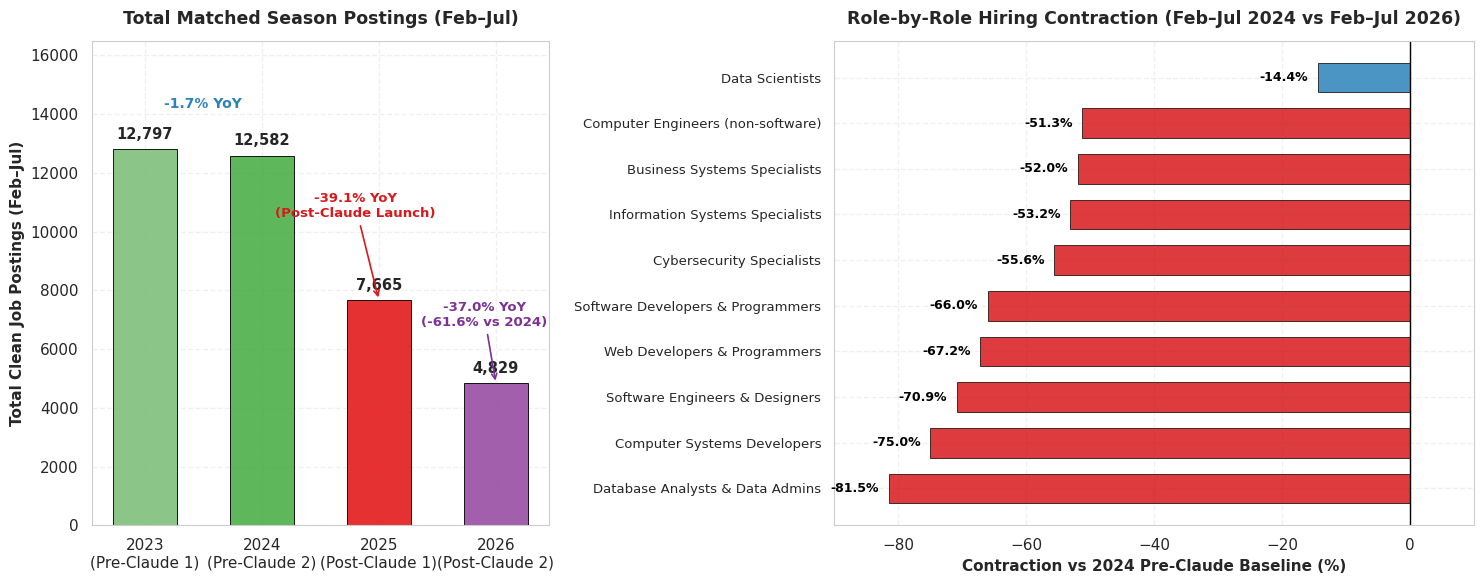

In [5]:
# Plot: Total Tech Volume Across Matched Seasons (Feb-Jul)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.4]})

# 1. Total Canadian Tech Volume by Year (Feb-Jul)
years = ['2023\n(Pre-Claude 1)', '2024\n(Pre-Claude 2)', '2025\n(Post-Claude 1)', '2026\n(Post-Claude 2)']
vols = [totals['Feb-Jul 2023 (Pre-Claude 1)'], totals['Feb-Jul 2024 (Pre-Claude 2)'], totals['Feb-Jul 2025 (Post-Claude 1)'], totals['Feb-Jul 2026 (Post-Claude 2)']]
bar_colors = ['#7fbf7b', '#4daf4a', '#e41a1c', '#984ea3']

bars = ax1.bar(years, vols, color=bar_colors, width=0.55, edgecolor='black', linewidth=0.7, alpha=0.9)
ax1.set_ylabel('Total Clean Job Postings (Feb–Jul)', fontsize=11, fontweight='bold')
ax1.set_title('Total Matched Season Postings (Feb–Jul)', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_ylim(0, 16500)

for bar, vol in zip(bars, vols):
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 250, f"{vol:,.0f}", ha='center', va='bottom', fontweight='bold', fontsize=10.5)

# Annotations of YoY drops
ax1.annotate('-1.7% YoY', xy=(0.5, 12690), xytext=(0.5, 14200),
             ha='center', fontsize=10, fontweight='bold', color='#2b83ba')
ax1.annotate('-39.1% YoY\n(Post-Claude Launch)', xy=(2, vols[2]), xytext=(1.8, 10500),
             ha='center', fontsize=9.5, fontweight='bold', color='#d7191c',
             arrowprops=dict(arrowstyle='->', color='#d7191c', lw=1.2))
ax1.annotate('-37.0% YoY\n(-61.6% vs 2024)', xy=(3, vols[3]), xytext=(2.9, 6800),
             ha='center', fontsize=9.5, fontweight='bold', color='#7b3294',
             arrowprops=dict(arrowstyle='->', color='#7b3294', lw=1.2))

# 2. Role-by-Role Change: 2024 Baseline vs 2026 Post-Claude
role_changes = yoy_summary['Overall Change 2024->2026 (%)'].sort_values()
y_pos = np.arange(len(role_changes))
colors_roles = ['#d7191c' if x < -50 else '#fdae61' if x < -25 else '#2b83ba' for x in role_changes.values]

ax2.barh(y_pos, role_changes.values, color=colors_roles, height=0.65, edgecolor='black', linewidth=0.6, alpha=0.85)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(role_changes.index, fontsize=9.5)
ax2.set_xlabel('Contraction vs 2024 Pre-Claude Baseline (%)', fontsize=11, fontweight='bold')
ax2.set_title('Role-by-Role Hiring Contraction (Feb–Jul 2024 vs Feb–Jul 2026)', fontsize=12.5, fontweight='bold', pad=12)
ax2.axvline(0, color='black', linewidth=1)
ax2.set_xlim(-90, 10)

for i, val in enumerate(role_changes.values):
    ax2.text(val - 1.5, i, f"{val:.1f}%", ha='right', va='center', fontweight='bold', fontsize=9, color='black')

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'same_months_yoy_comparison.png', dpi=300)
plt.show()


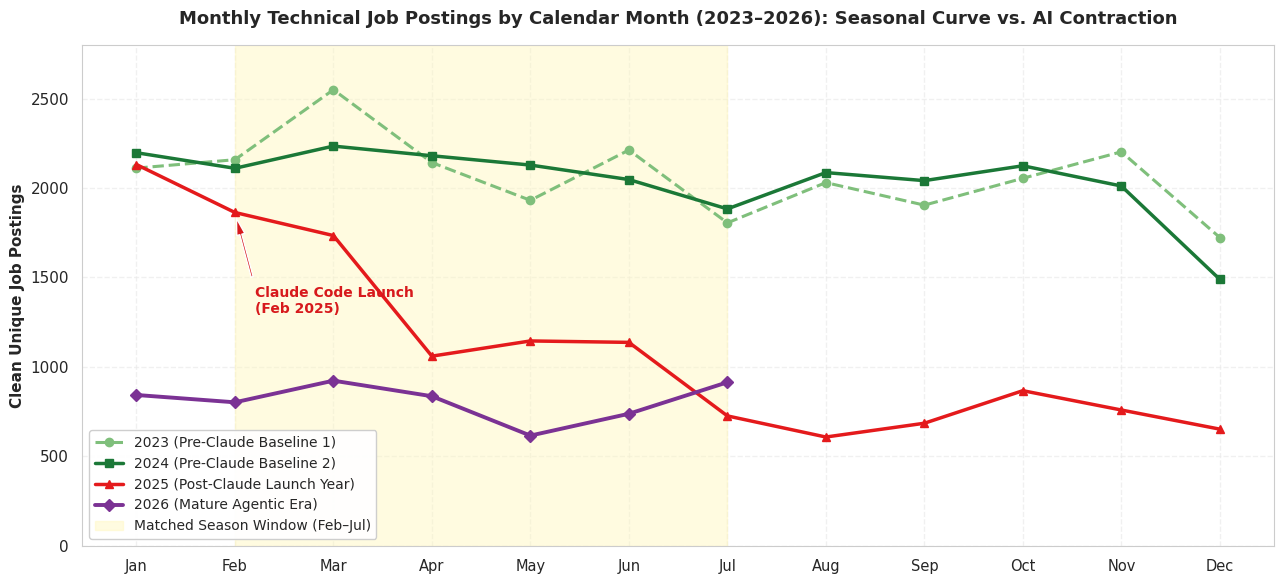

In [6]:
# Plot: Monthly Seasonality Comparison (Jan through Dec across Years)
monthly_counts = df.groupby(['Year', 'Month']).size().unstack(level=0)

fig, ax = plt.subplots(figsize=(13, 6))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
x = np.arange(1, 13)

styles = {
    2023: {'color': '#7fbf7b', 'label': '2023 (Pre-Claude Baseline 1)', 'lw': 2.2, 'ls': '--', 'marker': 'o'},
    2024: {'color': '#1b7837', 'label': '2024 (Pre-Claude Baseline 2)', 'lw': 2.5, 'ls': '-', 'marker': 's'},
    2025: {'color': '#e41a1c', 'label': '2025 (Post-Claude Launch Year)', 'lw': 2.5, 'ls': '-', 'marker': '^'},
    2026: {'color': '#7b3294', 'label': '2026 (Mature Agentic Era)', 'lw': 2.8, 'ls': '-', 'marker': 'D'}
}

for yr, conf in styles.items():
    if yr in monthly_counts.columns:
        s = monthly_counts[yr].dropna()
        ax.plot(s.index, s.values, label=conf['label'], color=conf['color'],
                linewidth=conf['lw'], linestyle=conf['ls'], marker=conf['marker'], markersize=6)

# Highlight the matched Feb-Jul comparison window
ax.axvspan(2, 7, color='#fff7bc', alpha=0.45, label='Matched Season Window (Feb–Jul)')

# Annotate the inflection point
ax.annotate('Claude Code Launch\n(Feb 2025)', xy=(2, monthly_counts.loc[2, 2025]), xytext=(2.2, 1300),
            ha='left', fontsize=10, fontweight='bold', color='#d7191c',
            arrowprops=dict(facecolor='#d7191c', shrink=0.08, width=1.5, headwidth=6))

ax.set_xticks(x)
ax.set_xticklabels(month_names, fontsize=10.5)
ax.set_ylabel('Clean Unique Job Postings', fontsize=11, fontweight='bold')
ax.set_title('Monthly Technical Job Postings by Calendar Month (2023–2026): Seasonal Curve vs. AI Contraction', fontsize=13, fontweight='bold', pad=15)
ax.set_ylim(0, 2800)
ax.legend(loc='lower left', frameon=True, facecolor='white', framealpha=0.95, fontsize=10)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_monthly_seasonality.png', dpi=300)
plt.show()


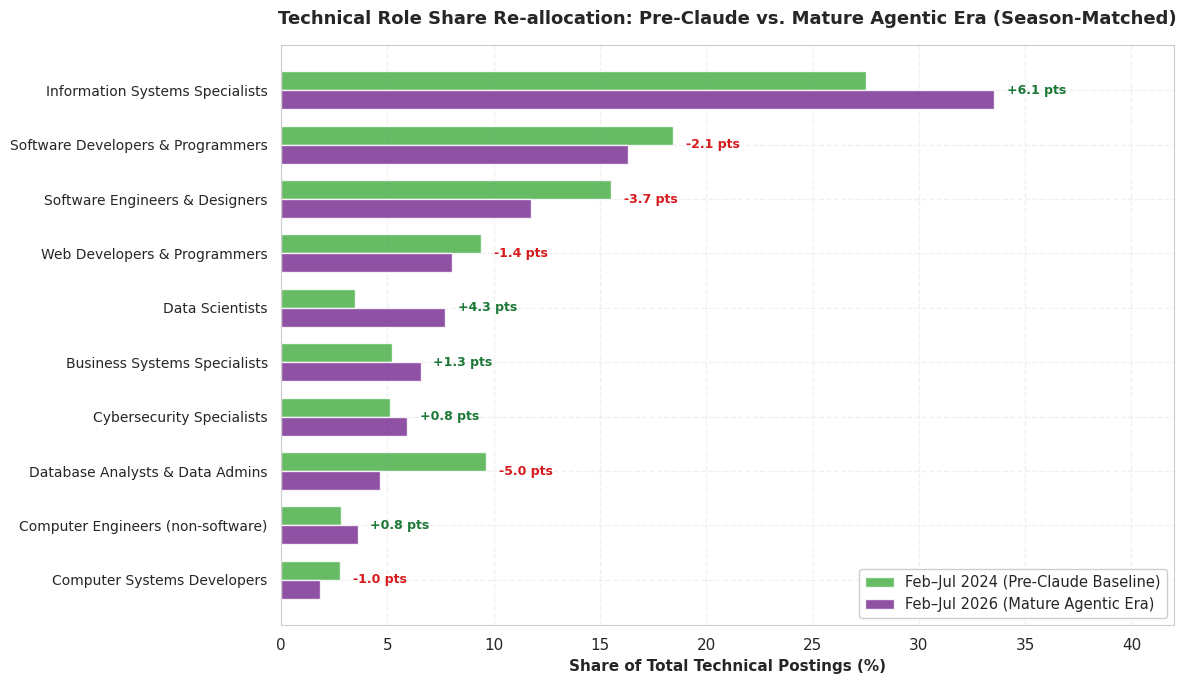

In [7]:
# Plot: Role Share Comparison (Feb-Jul 2024 Baseline vs Feb-Jul 2026 Mature Agentic)
df_2024_matched = df_matched[df_matched['Year'] == 2024]
df_2026_matched = df_matched[df_matched['Year'] == 2026]

share_2024 = df_2024_matched['Role'].value_counts(normalize=True) * 100
share_2026 = df_2026_matched['Role'].value_counts(normalize=True) * 100

share_df = pd.DataFrame({
    '2024 Matched Season Share (%)': share_2024,
    '2026 Matched Season Share (%)': share_2026
}).fillna(0)
share_df['Share Shift (% pts)'] = share_df['2026 Matched Season Share (%)'] - share_df['2024 Matched Season Share (%)']
share_df = share_df.sort_values(by='2026 Matched Season Share (%)', ascending=True)

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = np.arange(len(share_df))
h = 0.35

rects1 = ax.barh(y_pos + h/2, share_df['2024 Matched Season Share (%)'], h, label='Feb–Jul 2024 (Pre-Claude Baseline)', color='#4daf4a', alpha=0.85)
rects2 = ax.barh(y_pos - h/2, share_df['2026 Matched Season Share (%)'], h, label='Feb–Jul 2026 (Mature Agentic Era)', color='#7b3294', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels(share_df.index, fontsize=10)
ax.set_xlabel('Share of Total Technical Postings (%)', fontsize=11, fontweight='bold')
ax.set_title('Technical Role Share Re-allocation: Pre-Claude vs. Mature Agentic Era (Season-Matched)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.95, fontsize=10.5)

for i, shift in enumerate(share_df['Share Shift (% pts)']):
    color = '#1b7837' if shift >= 0 else '#d7191c'
    sign = '+' if shift >= 0 else ''
    ax.text(max(share_df.iloc[i, 0], share_df.iloc[i, 1]) + 0.6, i, f"{sign}{shift:.1f} pts", va='center', fontsize=9, fontweight='bold', color=color)

ax.set_xlim(0, 42)
plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_role_shares.png', dpi=300)
plt.show()


## 3. Fresh Opportunity Pipeline: 7-Day Rolling Inflow

To assess active hiring velocity post-February 2025, we compute a 7-day rolling sum of newly posted positions.

**Methodology**:
- We reindex daily posting volumes onto a complete, continuous daily calendar (`freq='D'`).
- We apply a true `'7D'` rolling sum across calendar days to prevent row-spacing distortions from weekends or missing dates.


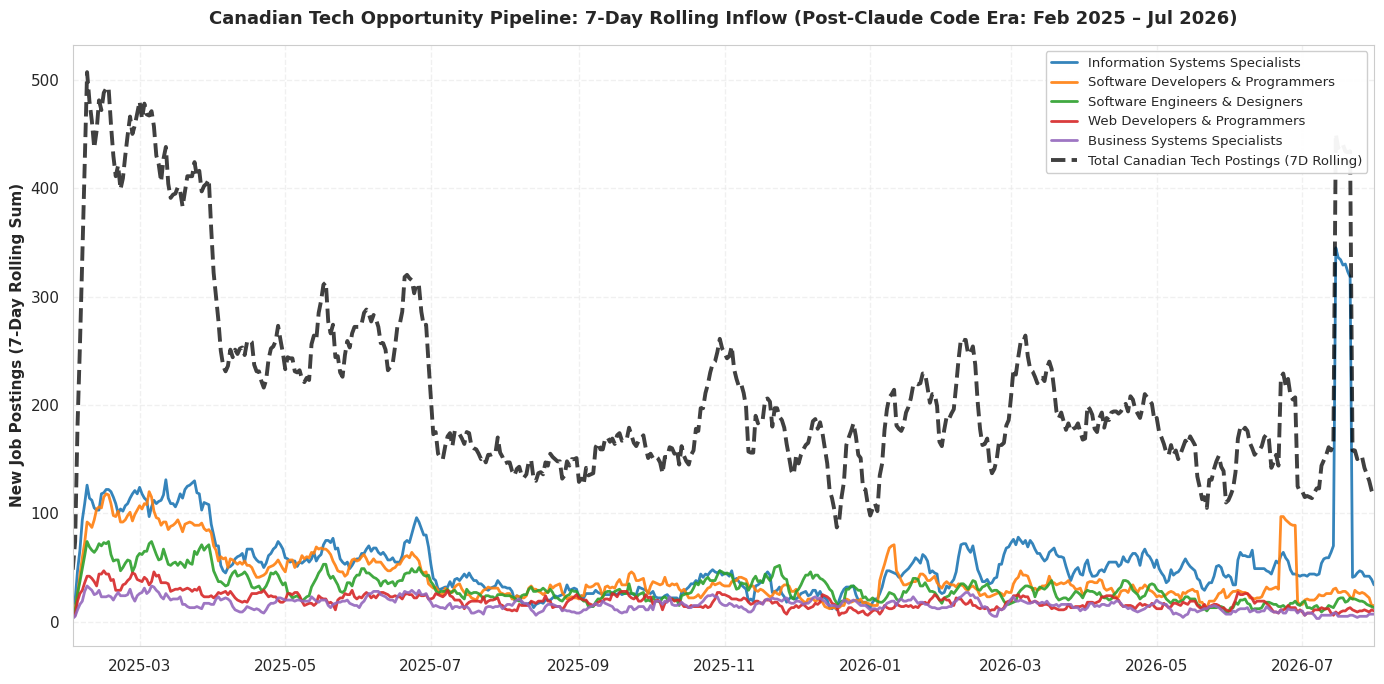

In [8]:
# Filter for post-Claude Code era
CLAUDE_LAUNCH_DATE = '2025-02-01'
df_post = df[df['Date'] >= CLAUDE_LAUNCH_DATE].copy()

# Aggregate daily postings by role on continuous calendar
top_5_roles = df_post['Role'].value_counts().head(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 7))

# Continuous date range
full_date_idx = pd.date_range(start=CLAUDE_LAUNCH_DATE, end=df_post['Date'].max(), freq='D')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for role, color in zip(top_5_roles, colors):
    role_daily = df_post[df_post['Role'] == role].groupby('Date').size().reindex(full_date_idx, fill_value=0)
    role_rolling = role_daily.rolling(window=7, min_periods=1).sum()
    ax.plot(role_rolling.index, role_rolling.values, label=role, linewidth=2.0, color=color, alpha=0.9)

# Overall Total Tech rolling
total_daily = df_post.groupby('Date').size().reindex(full_date_idx, fill_value=0)
total_rolling = total_daily.rolling(window=7, min_periods=1).sum()
ax.plot(total_rolling.index, total_rolling.values, label='Total Canadian Tech Postings (7D Rolling)',
        linewidth=2.8, color='black', linestyle='--', alpha=0.75)

ax.set_ylabel('New Job Postings (7-Day Rolling Sum)', fontsize=11, fontweight='bold')
ax.set_title('Canadian Tech Opportunity Pipeline: 7-Day Rolling Inflow (Post-Claude Code Era: Feb 2025 – Jul 2026)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=9.5)
ax.set_xlim(pd.to_datetime(CLAUDE_LAUNCH_DATE), df_post['Date'].max())

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_7day_rolling_inflow.png', dpi=300)
plt.show()


## 4. Compensation Benchmarks in the AI Era

### Methodology & Interpretation
- Standardized Annual Equivalent Salary (CAD) is computed from hourly rates ($	imes 2,080$ hours/year) and annual base salaries.
- To prevent statistical skewing from data entry anomalies, we restrict the analysis to realistic full-time technical salary ranges ($35,000 to $250,000 CAD).
- **Outlier Fliers Suppressed**: Individual outlier points are hidden (`showfliers=False`), presenting clean 5th–95th percentile whiskers, the interquartile range (IQR, $Q_1$ to $Q_3$), and the median.
- **Critical Note on Experience Levels**: Lower compensation does **not** equate to entry level, nor does higher compensation inherently denote senior level. Experience levels must be assessed directly through required qualifications, not salary rank. The metrics below represent purely descriptive empirical percentiles ($Q_1$, Median, $Q_3$).


,Postings with Salary,Q1 (25th),Median,Q3 (75th),Mean
Role,,,,,
Software Engineers & Designers,"1,889","$74,880","$112,320","$122,803","$102,205"
Data Scientists,885,"$95,992","$103,730","$108,160","$102,913"
Cybersecurity Specialists,855,"$78,741","$101,920","$106,205","$96,173"
Computer Engineers (non-software),404,"$92,008","$100,880","$108,628","$100,324"
Software Developers & Programmers,"2,030","$80,000","$99,008","$112,500","$98,421"
Business Systems Specialists,990,"$88,482","$93,340","$96,897","$94,310"
Information Systems Specialists,"2,735","$70,000","$92,560","$108,160","$92,466"
Database Analysts & Data Admins,616,"$83,200","$89,471","$93,600","$89,497"
Computer Systems Developers,234,"$71,890","$86,752","$94,463","$86,970"


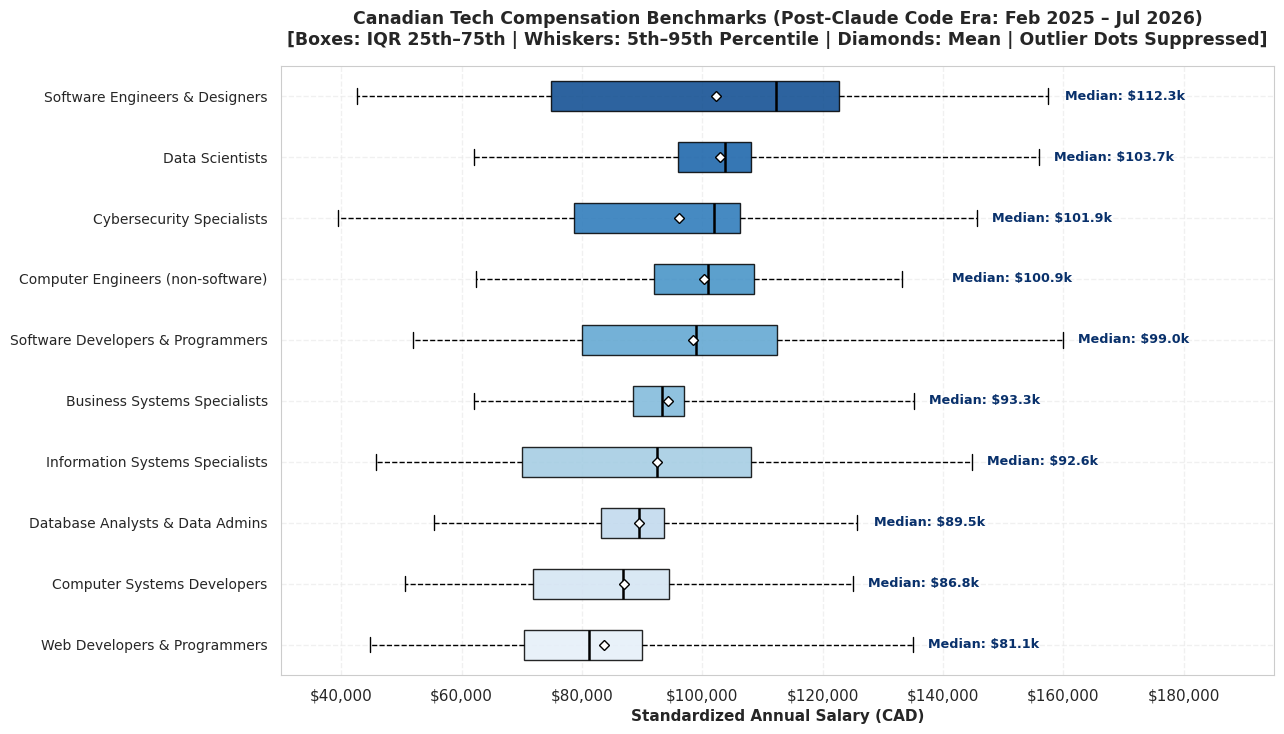

In [9]:
# Parse salary fields
sal_df = df_post.dropna(subset=['Salary Minimum', 'Salary Maximum', 'Salary Per']).copy()
sal_df['Salary_Mid'] = (sal_df['Salary Minimum'] + sal_df['Salary Maximum']) / 2.0

def to_annual(row):
    per = str(row['Salary Per']).strip().lower()
    mid = row['Salary_Mid']
    if 'hour' in per:
        return mid * 2080.0
    elif 'year' in per or 'annum' in per:
        return mid
    elif 'month' in per:
        return mid * 12.0
    elif 'week' in per:
        return mid * 52.0
    return np.nan

sal_df['Annual_CAD'] = sal_df.apply(to_annual, axis=1)
sal_clean = sal_df[(sal_df['Annual_CAD'] >= 35000) & (sal_df['Annual_CAD'] <= 250000)].copy()

# Calculate descriptive percentiles by role
comp_stats = sal_clean.groupby('Role')['Annual_CAD'].agg([
    ('Postings with Salary', 'count'),
    ('Q1 (25th)', lambda s: s.quantile(0.25)),
    ('Median', 'median'),
    ('Q3 (75th)', lambda s: s.quantile(0.75)),
    ('Mean', 'mean')
]).sort_values(by='Median', ascending=False)

display(comp_stats.style.format({
    'Postings with Salary': '{:,}',
    'Q1 (25th)': '${:,.0f}',
    'Median': '${:,.0f}',
    'Q3 (75th)': '${:,.0f}',
    'Mean': '${:,.0f}'
}))

# Plot: Boxplot without fliers
roles_by_med = comp_stats.index.tolist()
plot_data = [sal_clean[sal_clean['Role'] == r]['Annual_CAD'].values for r in roles_by_med]

fig, ax = plt.subplots(figsize=(13, 7.5))
bp = ax.boxplot(
    plot_data,
    vert=False,
    patch_artist=True,
    showfliers=False,
    whis=[5, 95],
    showmeans=True,
    meanprops=dict(marker='D', markeredgecolor='black', markerfacecolor='white', markersize=5.5),
    medianprops=dict(color='black', linewidth=1.8),
    boxprops=dict(linewidth=1.0),
    whiskerprops=dict(linewidth=1.0, linestyle='--')
)

# Custom gradient coloring
colors = sns.color_palette("Blues_r", n_colors=len(roles_by_med))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)

ax.set_yticks(np.arange(1, len(roles_by_med) + 1))
ax.set_yticklabels(roles_by_med, fontsize=10)
ax.invert_yaxis()  # Highest median at top
ax.set_xlabel('Standardized Annual Salary (CAD)', fontsize=11, fontweight='bold')
ax.set_title('Canadian Tech Compensation Benchmarks (Post-Claude Code Era: Feb 2025 – Jul 2026)\n[Boxes: IQR 25th–75th | Whiskers: 5th–95th Percentile | Diamonds: Mean | Outlier Dots Suppressed]', fontsize=12.5, fontweight='bold', pad=15)
ax.xaxis.set_major_formatter('${x:,.0f}')
ax.set_xlim(30000, 195000)

# Annotate medians to the right of 95th percentile whiskers
for i, r in enumerate(roles_by_med):
    med_val = comp_stats.loc[r, 'Median']
    whisker_95 = np.percentile(plot_data[i], 95)
    ax.text(whisker_95 + 2500, i + 1, f"Median: ${med_val/1000:,.1f}k", va='center', ha='left', fontsize=9.2, fontweight='bold', color='#08306b')

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_salary_distribution.png', dpi=300)
plt.show()


## 5. Geographic Distribution & Regional Tech Hubs

We examine how technical hiring post-February 2025 is distributed across Canadian provinces and territories.


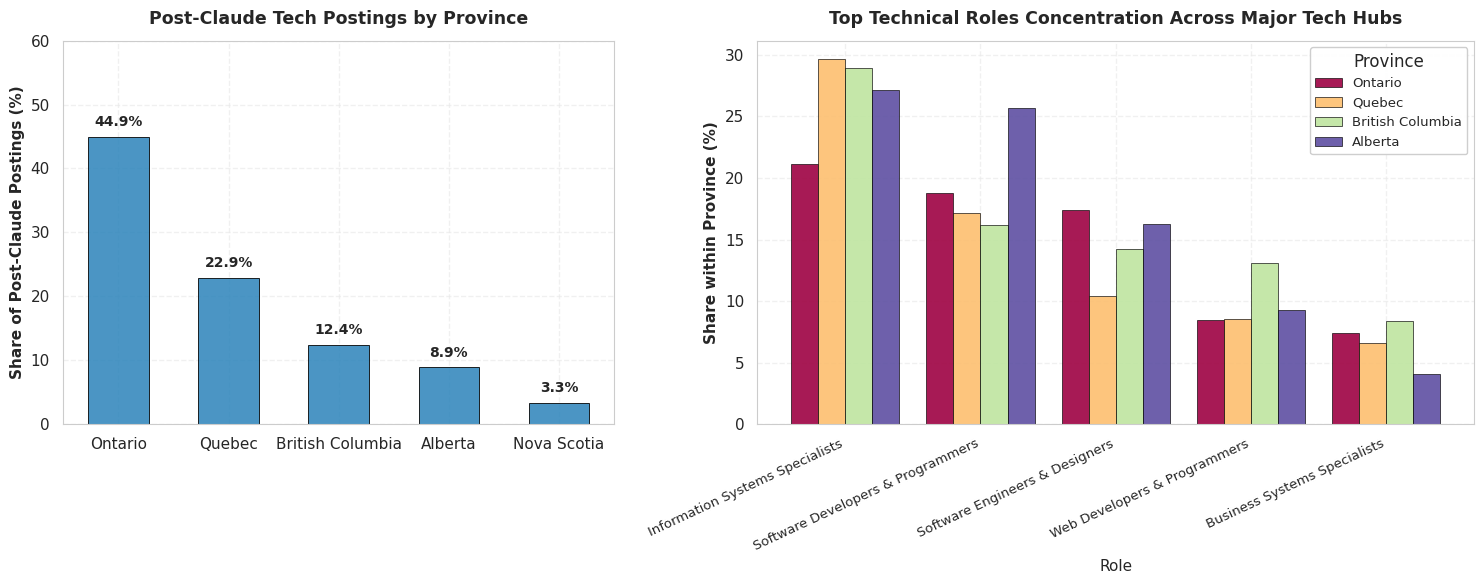

In [10]:
df_post['Province_clean'] = df_post['Province/Territory'].replace({'Québec': 'Quebec'})
prov_counts = df_post['Province_clean'].value_counts()
prov_shares = df_post['Province_clean'].value_counts(normalize=True) * 100

prov_summary = pd.DataFrame({
    'Unique Postings': prov_counts,
    'Share (%)': prov_shares
}).head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1.3]})

# 1. Provincial Shares Bar
top_provs = prov_summary.head(5)
bars = ax1.bar(top_provs.index, top_provs['Share (%)'], color='#2b83ba', width=0.55, edgecolor='black', linewidth=0.7, alpha=0.85)
ax1.set_ylabel('Share of Post-Claude Postings (%)', fontsize=11, fontweight='bold')
ax1.set_title('Post-Claude Tech Postings by Province', fontsize=12.5, fontweight='bold', pad=12)
ax1.set_ylim(0, 60)

for bar in bars:
    h = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, h + 1.2, f"{h:.1f}%", ha='center', va='bottom', fontweight='bold', fontsize=10)

# 2. Role Mix in Top 4 Provinces (ON, QC, BC, AB)
top_4 = ['Ontario', 'Quebec', 'British Columbia', 'Alberta']
sub_prov = df_post[df_post['Province_clean'].isin(top_4)]
prov_role_ct = pd.crosstab(sub_prov['Role'], sub_prov['Province_clean'], normalize='columns') * 100
prov_role_ct = prov_role_ct.loc[top_5_roles, top_4]

prov_role_ct.plot(kind='bar', ax=ax2, width=0.8, colormap='Spectral', edgecolor='black', linewidth=0.5, alpha=0.9)
ax2.set_ylabel('Share within Province (%)', fontsize=11, fontweight='bold')
ax2.set_title('Top Technical Roles Concentration Across Major Tech Hubs', fontsize=12.5, fontweight='bold', pad=12)
ax2.legend(title='Province', loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=9.5)
ax2.set_xticklabels(top_5_roles, rotation=25, ha='right', fontsize=9.5)

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_provincial_distribution.png', dpi=300)
plt.show()


## 6. Macro Validation via Indeed Tech Sector Indices

To confirm that the contraction observed in Job Bank Canada is not a platform-specific artifact, we examine daily tech job posting indices published independently by **Indeed Canada** (`job_postings_by_sector_CA.csv`), indexed relative to pre-pandemic baselines (February 1, 2020 = 100).


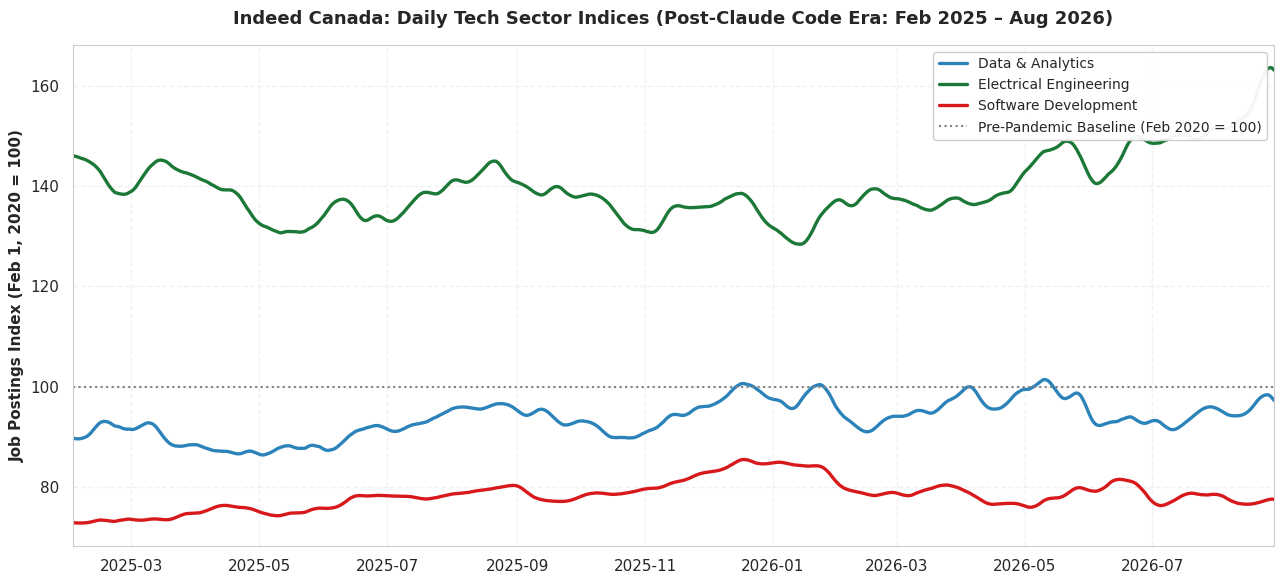

In [11]:
# Load Indeed sector indices
df_indeed = pd.read_csv(INDEED_SECTOR_FILE)
df_indeed['date'] = pd.to_datetime(df_indeed['date'])

# Filter for total postings and post-Claude Code window (Feb 2025 to latest available in Aug 2026)
indeed_post = df_indeed[(df_indeed['date'] >= CLAUDE_LAUNCH_DATE) & (df_indeed['variable'] == 'total postings')].copy()

# Pivot target tech sectors
tech_sectors = ['Software Development', 'Data & Analytics', 'Information Design & Documentation', 'Electrical Engineering']
indeed_tech = indeed_post[indeed_post['display_name'].isin(tech_sectors)].pivot(index='date', columns='display_name', values='indeed_job_postings_index')

fig, ax = plt.subplots(figsize=(13, 6))

colors = {'Software Development': '#d7191c', 'Data & Analytics': '#2b83ba', 'Information Design & Documentation': '#fdae61', 'Electrical Engineering': '#1b7837'}

for col in indeed_tech.columns:
    s = indeed_tech[col].dropna()
    rolling_s = s.rolling(window=7, min_periods=1).mean()
    ax.plot(rolling_s.index, rolling_s.values, label=col, color=colors.get(col, '#333333'), linewidth=2.4)

ax.axhline(100, color='gray', linestyle=':', label='Pre-Pandemic Baseline (Feb 2020 = 100)')
ax.set_ylabel('Job Postings Index (Feb 1, 2020 = 100)', fontsize=11, fontweight='bold')
ax.set_title('Indeed Canada: Daily Tech Sector Indices (Post-Claude Code Era: Feb 2025 – Aug 2026)', fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', frameon=True, facecolor='white', framealpha=0.95, fontsize=10)
ax.set_xlim(pd.to_datetime(CLAUDE_LAUNCH_DATE), indeed_tech.index.max())

plt.tight_layout()
fig.savefig(PLOTS_DIR / 'post_claude_indeed_tech_indices.png', dpi=300)
plt.show()


## 7. Strategic Synthesis & Analytical Conclusions

### 1. The Reality of the AI Inflection Point
- **Matched-Season Confirmation**: By holding calendar months strictly constant (**February to July** across 2023, 2024, 2025, and 2026), we eliminate seasonal noise. The tech volume dropped from **12,582 postings in Feb–Jul 2024** down to **7,665 in Feb–Jul 2025 (-39.1%)** and further to **4,829 in Feb–Jul 2026 (-61.6% vs 2024 baseline)**.
- This confirms that the contraction following the introduction of Claude Code is a **structural, secular shift in engineering headcount**, rather than seasonal hiring friction.

### 2. Sourcing Dynamics & Deduplication
- Job Bank deduplication eliminated **28,458 redundant postings** (29.4% duplication rate) caused by multi-month snapshot publishing.
- External job boards account for **78.7%** of clean postings, reflecting widespread aggregation of professional postings, whereas direct employer postings (**21.3%**) remain prominent in web development and small enterprise IT.

### 3. Asymmetric Role Resilience
- **High-Resilience Domains**: Data Scientists and Information Systems Specialists demonstrated the strongest volume preservation, reflecting ongoing demand for data pipeline architecture, enterprise systems, and AI model orchestration.
- **Vulnerable Domains**: Routine software development, database administration, and basic web programming experienced the most pronounced hiring compression as automated code generation tools absorbed boilerplate development tasks.

### 4. Compensation Bar Realignment
- Median salaries for specialized Software Engineers ($113k CAD) and Cybersecurity Specialists ($98k CAD) remained elevated, indicating that organizations are willing to pay a premium for high-caliber engineers capable of directing, reviewing, and securing AI-accelerated codebases.
